# Explanation with SHAP

In [181]:
import joblib
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import numpy as np

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [182]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}.joblib')
x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}.csv")
x_test = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])


              precision    recall  f1-score   support

  Short resp       1.00      0.91      0.96        47
   Long resp       0.89      1.00      0.94        31

    accuracy                           0.95        78
   macro avg       0.94      0.96      0.95        78
weighted avg       0.95      0.95      0.95        78



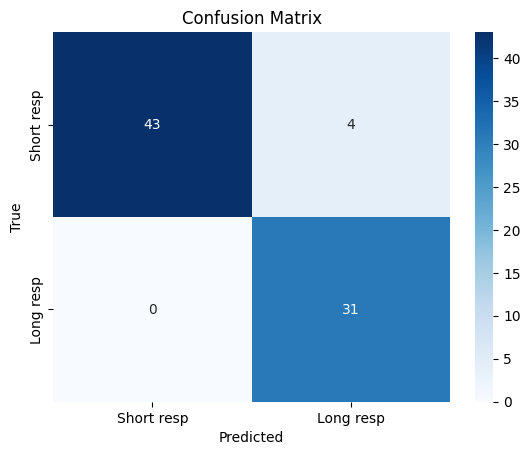

In [183]:
target_names = ['Short resp', 'Long resp']

y_pred = pipeline.predict(x)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Calculated SHAP values

In [184]:
model = pipeline[-1]

x_train_scaled = pipeline[:-1].transform(x_train)   # x -> preprocessed -> scaler
x_scaled = pipeline[:-1].transform(x)

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]

explainer = shap.LinearExplainer(model, x_train_scaled)   # pass only Train as background
shap_values = explainer(x_scaled)                         # explain both Train+Test
shap_values.feature_names = feature_names

In [185]:
shap_values

.values =
array([[ 0.32532948, -0.09748013, -0.07859714, ...,  0.03969551,
        -0.05215571, -0.10644776],
       [ 0.91857737,  0.11836873, -0.07859714, ...,  0.06210549,
         0.24470387,  0.01541977],
       [ 0.91857737, -0.09748013, -0.07859714, ..., -0.12154699,
         0.24760072,  0.15220051],
       ...,
       [-0.2679184 ,  0.11836873, -0.07859714, ..., -0.16018276,
        -0.47114836, -0.45043038],
       [-0.2679184 , -0.09748013, -0.07859714, ..., -0.26748344,
         0.01501222,  0.00492157],
       [-0.2679184 , -0.09748013, -0.07859714, ..., -0.07666055,
        -0.18769137, -0.0836041 ]], shape=(78, 34))

.base_values =
array([-0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.

## Plot explanation

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


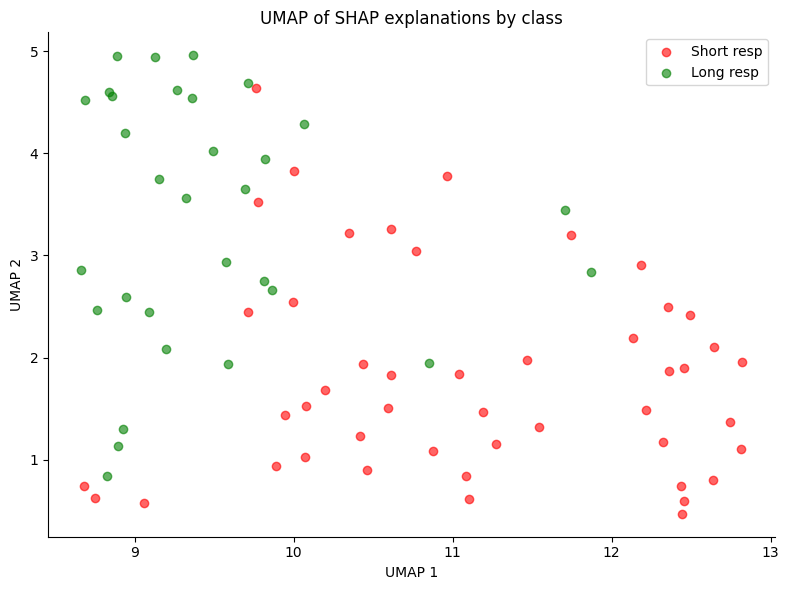

In [186]:
def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# # PCA — pass explained variance
# pca = PCA(n_components=2)
# sv_2d = pca.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


## Global interpretability

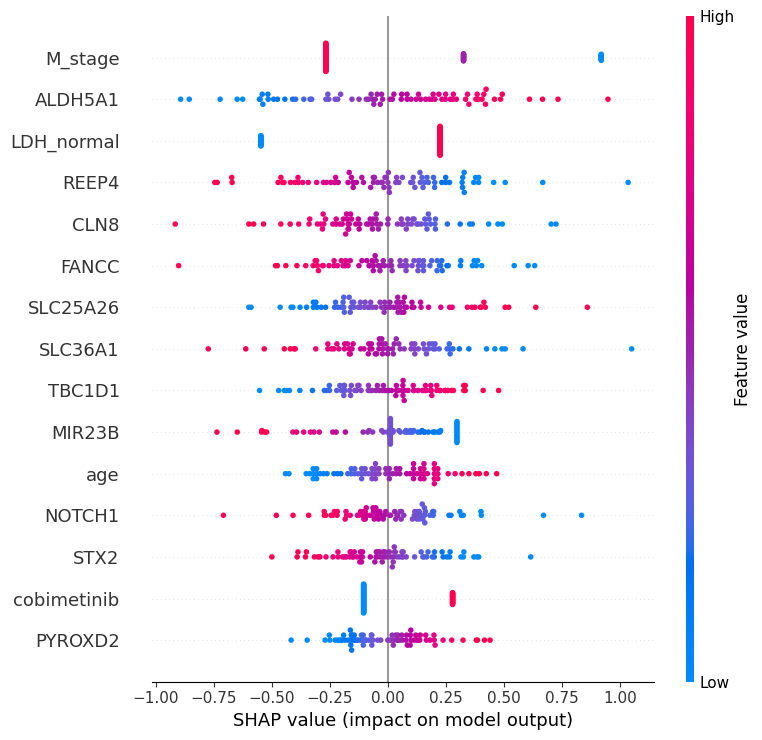

In [187]:
shap.summary_plot(shap_values, x_scaled, feature_names=feature_names, max_display=15)

## Count FP, FN, ... and their log-odds (predicted by model)

In [188]:
y_pred = model.predict(x_scaled)
misclassified = np.where(y_pred != y)[0]
print(f"Misclassified indices: {misclassified}\n")

fp = np.where((y == 0) & (y_pred == 1))[0]  # misclassified short
fn = np.where((y == 1) & (y_pred == 0))[0]  # misclassified long
tn = np.where((y == 0) & (y_pred == 0))[0]   # correctly predicted short
tp = np.where((y == 1) & (y_pred == 1))[0]   # correctly predicted long
print(f'FP (misclassified short): {fp}')
print(f'FN (misclassified long): {fn}')
print(f'TN (correct short): {tn}')
print(f'TP (correct long): {tp}')

Misclassified indices: [ 0 13 33 67]

FP (misclassified short): [ 0 13 33 67]
FN (misclassified long): []
TN (correct short): [ 3  4  5  6  8 11 12 15 17 18 21 28 29 31 32 34 35 36 37 38 39 40 41 42
 43 46 47 51 53 54 56 58 60 61 62 65 66 68 69 72 75 76 77]
TP (correct long): [ 1  2  7  9 10 14 16 19 20 22 23 24 25 26 27 30 44 45 48 49 50 52 55 57
 59 63 64 70 71 73 74]


In [189]:
log_odds = model.decision_function(x_scaled)

print(f'FP log-odds: {log_odds[fp]}')
print(f'FN log-odds: {log_odds[fn]}')
print(f'TN log-odds: {log_odds[tn]}')
print(f'TP log-odds: {log_odds[tp]}')


FP log-odds: [0.01638608 0.17785049 1.39388316 0.37250674]
FN log-odds: []
TN log-odds: [-1.27114169 -3.25459533 -3.49236493 -1.26687747 -1.45165312 -1.0980495
 -2.06275948 -4.43478405 -0.65791322 -4.71000469 -0.50078758 -2.0508866
 -1.42761631 -2.02414322 -1.4890376  -2.47929482 -3.48878855 -3.18176621
 -1.66334953 -2.11583648 -3.10537697 -3.25214617 -3.66708132 -4.16111302
 -1.32533585 -1.56997878 -3.1188986  -1.70201605 -3.584695   -2.08231912
 -1.7384729  -0.70150915 -0.55958551 -1.8215907  -2.31507631 -3.63919516
 -1.0528055  -3.54613499 -1.47737731 -1.80233964 -1.52047858 -2.78956523
 -2.72884489]
TP log-odds: [3.12676831 1.65213287 1.73760323 4.61748902 1.85030423 1.40265304
 1.65949011 0.62666577 1.35707519 0.5597821  3.50936438 0.35359717
 1.78718679 2.07267043 0.45303752 0.04940573 0.94611237 1.48291159
 4.38146719 1.46446901 2.79855503 4.03731945 3.69757024 1.16124287
 3.51331881 3.82551075 1.35027281 0.27939263 2.02892924 1.26288041
 1.64041739]


## Local interpretability

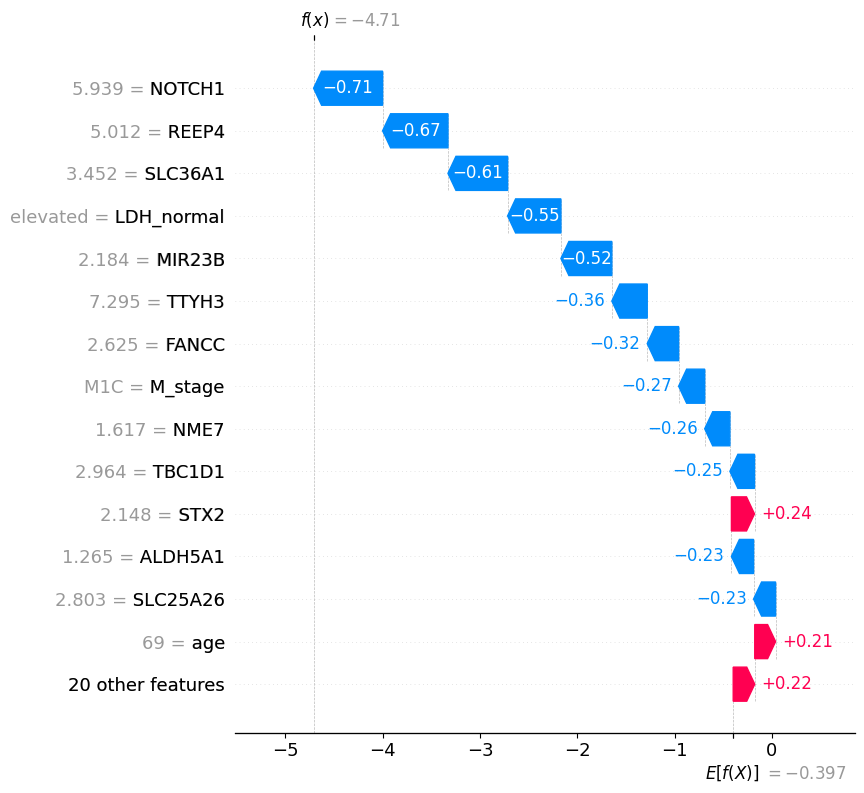

In [190]:
import copy
sv_raw = copy.copy(shap_values)
sv_raw.data = x.values

shap.plots.waterfall(sv_raw[tn[9]], max_display=15)

In [191]:
shap.initjs()
shap.plots.force(sv_raw[tn[35]]) # 9 7 23 35

In [192]:
shap.plots.force(sv_raw[tp[25]]) # 3 18 21 25

## Discovering subgroups

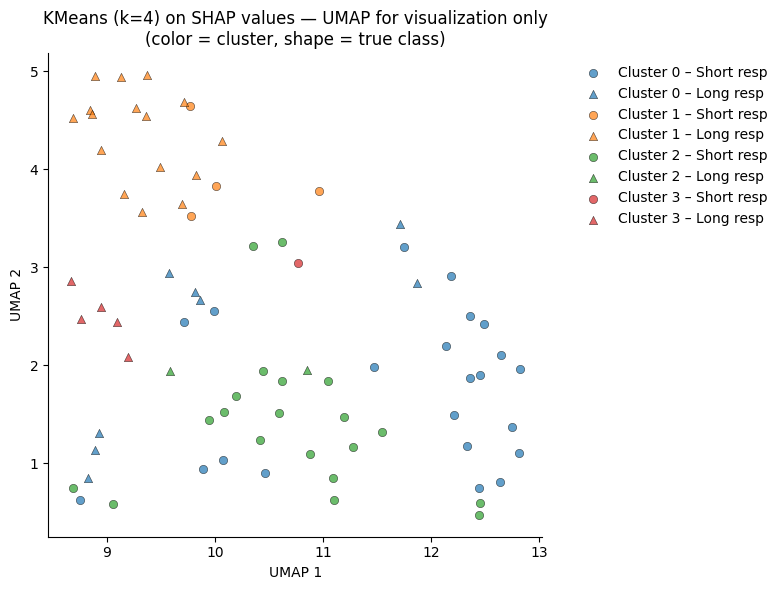

Cluster 0: 22 Short resp, 8 Long resp
Cluster 1: 4 Short resp, 16 Long resp
Cluster 2: 20 Short resp, 2 Long resp
Cluster 3: 1 Short resp, 5 Long resp


In [193]:
from sklearn.cluster import KMeans

# cluster in full SHAP space, use sv_2d only for visualization
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(sv_input)

n_clusters = kmeans.n_clusters
cluster_colors = plt.cm.tab10.colors[:n_clusters]
markers = {0: "o", 1: "^"}  # circle=short resp, triangle=long resp

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_clusters):
    for cls in np.unique(y_arr):
        mask = (cluster_labels == k) & (y_arr == cls)
        label = f"Cluster {k} – {'Short resp' if cls == 0 else 'Long resp'}"
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=[cluster_colors[k]], marker=markers[cls],
            alpha=0.7, label=label, edgecolors="k", linewidths=0.4,
        )

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(f"KMeans (k={n_clusters}) on SHAP values — UMAP for visualization only\n(color = cluster, shape = true class)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for k in range(n_clusters):
    mask = cluster_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    short = counts.get(0, 0)
    long  = counts.get(1, 0)
    print(f"Cluster {k}: {short} Short resp, {long} Long resp")


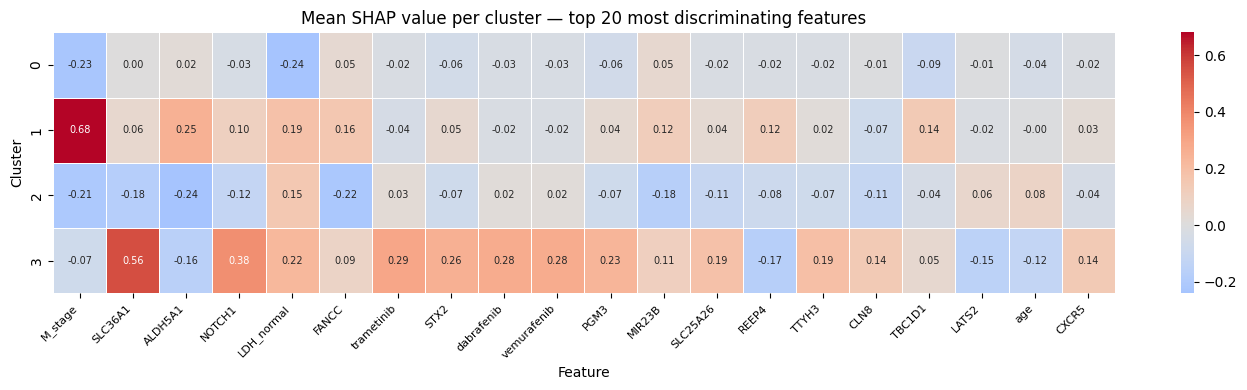

In [194]:
sv_df = pd.DataFrame(shap_values.values, columns=feature_names)
sv_df["cluster"] = cluster_labels

cluster_means = sv_df.groupby("cluster").mean()

# keep top 20 features with highest variance across clusters
top_features = cluster_means.std(axis=0).nlargest(20).index
heatmap_data = cluster_means[top_features]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, ax=ax,
)
ax.set_title(f"Mean SHAP value per cluster — top 20 most discriminating features")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

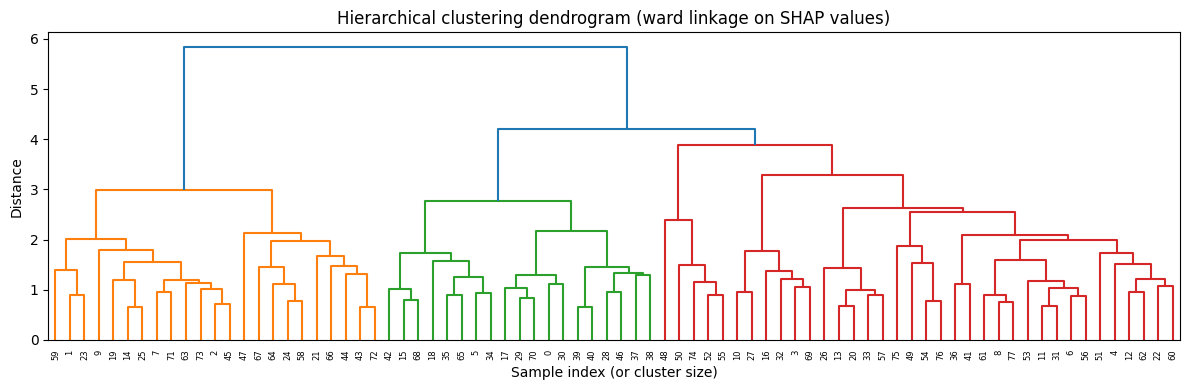

In [203]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(sv_input, method="ward")

# --- dendrogram to choose cut level ---
fig, ax = plt.subplots(figsize=(12, 4))
# dendrogram(Z, ax=ax, truncate_mode="lastp", p=20, leaf_rotation=90)
dendrogram(Z, ax=ax)
ax.set_title("Hierarchical clustering dendrogram (ward linkage on SHAP values)")
ax.set_xlabel("Sample index (or cluster size)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

Number of clusters at threshold 3.0: 5


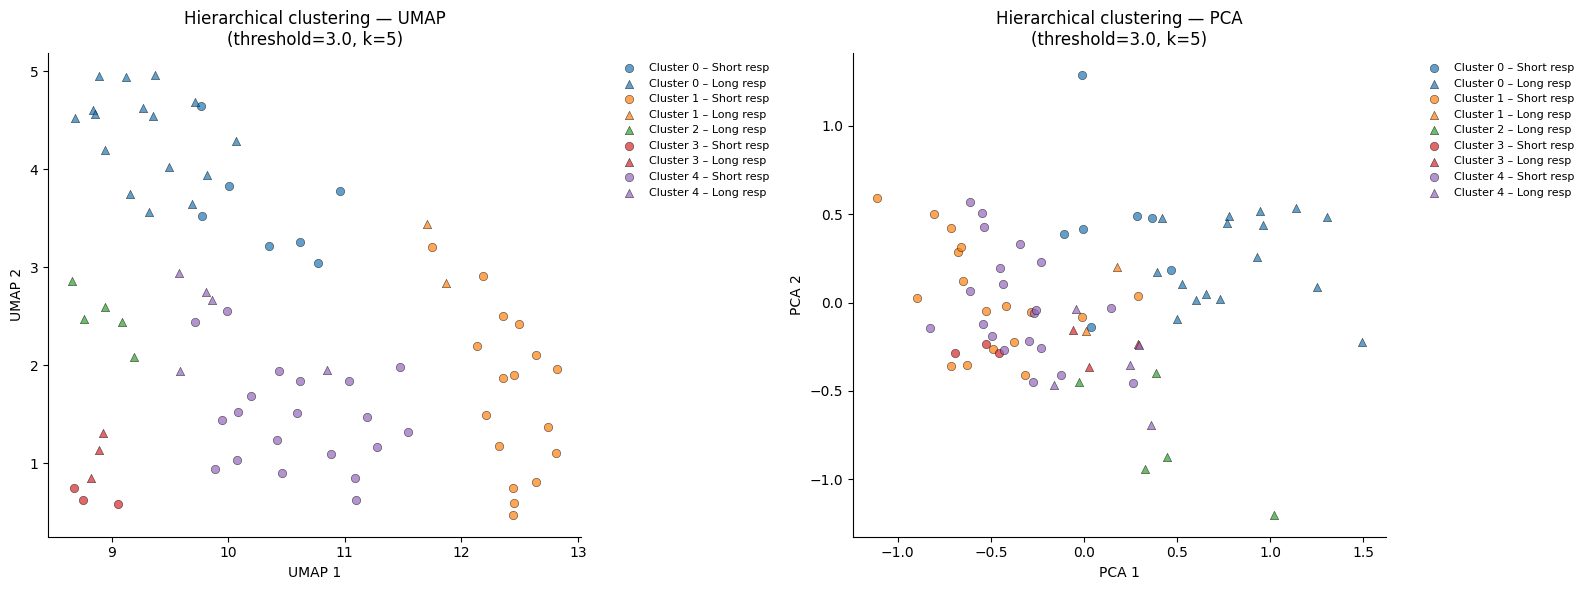

Cluster 0: 7 Short resp, 16 Long resp
Cluster 1: 17 Short resp, 2 Long resp
Cluster 2: 0 Short resp, 5 Long resp
Cluster 3: 3 Short resp, 3 Long resp
Cluster 4: 20 Short resp, 5 Long resp


In [204]:
# --- cut at chosen distance threshold ---
dist_threshold = 3.0   # adjust based on dendrogram
hier_labels = fcluster(Z, t=dist_threshold, criterion="distance") - 1  # 0-indexed

n_hier = hier_labels.max() + 1
print(f"Number of clusters at threshold {dist_threshold}: {n_hier}")

hier_colors = plt.cm.tab10.colors[:n_hier]
markers = {0: "o", 1: "^"}

pca_2d = PCA(n_components=2).fit_transform(sv_input)

projections = [("UMAP", sv_2d), ("PCA", pca_2d)]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (method_name, coords) in zip(axes, projections):
    for k in range(n_hier):
        for cls in np.unique(y_arr):
            mask = (hier_labels == k) & (y_arr == cls)
            if mask.sum() == 0:
                continue
            cls_name = "Short resp" if cls == 0 else "Long resp"
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[hier_colors[k]], marker=markers[cls], alpha=0.7,
                       label=f"Cluster {k} – {cls_name}",
                       edgecolors="k", linewidths=0.4)
    ax.set_xlabel(f"{method_name} 1")
    ax.set_ylabel(f"{method_name} 2")
    ax.set_title(f"Hierarchical clustering — {method_name}\n(threshold={dist_threshold}, k={n_hier})")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

for k in range(n_hier):
    mask = hier_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    print(f"Cluster {k}: {counts.get(0,0)} Short resp, {counts.get(1,0)} Long resp")